# Ancient Ambient Sound Level Comparison

This notebook compares two methods for estimating "ancient ambient" underwater noise levels:
- **Method 1 (ship-filtered)**: Excludes time windows with ship presence, using AIS-derived ship metrics
- **Method 2 (unfiltered)**: Uses rolling percentile statistics over longer windows without ship filtering

**Ship data analysis date range**: 2026-02-07 to 2026-02-13

> **Environment requirement**: This notebook requires the `orcasound` conda environment.
> Activate it before launching Jupyter: `conda activate orcasound`

In [104]:
import sys
from datetime import datetime, timedelta
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, '../src')
from orcasound_noise.analysis.partitioned_accessor import PartitionedAccessor
from orcasound_noise.utils.hydrophone import Hydrophone

In [137]:
# Analysis parameters
HYDROPHONE = Hydrophone.ORCASOUND_LAB_DATA  # data_2.0 folder on acoustic-sandbox
ANALYSIS_END = datetime(2026, 2, 13, 23, 59, 59)
SHIP_DATA_START = datetime(2026, 2, 7)
EXTENDED_START = datetime(2026, 1, 31)
AWS_PROFILE = "ambient-sound-team"
AWS_REGION = "us-west-2"
CONFIDENCE_THRESHOLD = 0.5
COMM_BAND = (500, 15000)
SHIP_BAND = (67, 200)   # ship noise range; effective 67-200 Hz (lowest PSD band is 67 Hz)
PERCENTILES = [0.05, 0.10, 0.25, 0.50]
METHOD1_WINDOWS = [1, 2, 5, 7]   # days, capped by ship data availability
METHOD2_WINDOWS = [1, 2, 3, 5, 7, 10, 14]  # days, no ship data required
S3_SHIP_METRICS = "s3://acoustic-sandbox/ambient-sound-analysis/temp_ship_metrics"

# Make sure downstream S3 readers (Polars/object_store) use the intended AWS profile.
import os
os.environ["AWS_PROFILE"] = AWS_PROFILE
os.environ["AWS_REGION"] = AWS_REGION

## 1. Ship Metrics Data Access

Load pre-computed ship track metrics from S3. Data covers 2026-02-07 to 2026-02-13 and is partitioned by year/month/day.

**Known data quirk**: The `bb_series` column contains a constant value of approximately −171.64 dB for many ship passages. This equals the negated `bb_ref` constant from `Hydrophone.ORCASOUND_LAB` and indicates that the broadband acoustic series was not populated for those passages (e.g., ship was too far from the hydrophone or there was an acoustic data gap during that time). This analysis uses raw acoustic data from `PartitionedAccessor` directly, not the pre-aggregated values in the ship metrics file.

In [106]:
# Load a single day as a schema/data check
ship_sample = pl.scan_parquet(
    f"{S3_SHIP_METRICS}/year=2026/month=02/day=11/*.parquet",
    storage_options={"aws_profile": AWS_PROFILE, "aws_region": AWS_REGION}
).collect()

print(f"Shape: {ship_sample.shape}")
print(f"\nColumns ({len(ship_sample.columns)}):")
for col, dtype in zip(ship_sample.columns, ship_sample.dtypes):
    print(f"  {col}: {dtype}")
print(f"\nSample rows:")
ship_sample.head(3)

Shape: (82, 27)

Columns (27):
  id_track: Int64
  s_timestamp: Datetime(time_unit='ns', time_zone=None)
  l_timestamp: Datetime(time_unit='ns', time_zone=None)
  duration: Float64
  avg_speed: Float64
  max_speed: Float64
  min_speed: Float64
  distance: Float64
  curviness: Float64
  confidence: Float64
  min_dist: Float64
  is_isolated: Boolean
  mmsi: String
  imo: String
  name: String
  draft: Float64
  type_id: String
  type: Float64
  comm_avg: Float64
  comm_95th: Float64
  comm_75th: Float64
  comm_50th: Float64
  bb_avg: Float64
  bb_95th: Float64
  bb_50th: Float64
  comm_bb_series: List(Float64)
  bb_series: List(Float64)

Sample rows:


id_track,s_timestamp,l_timestamp,duration,avg_speed,max_speed,min_speed,distance,curviness,confidence,min_dist,is_isolated,mmsi,imo,name,draft,type_id,type,comm_avg,comm_95th,comm_75th,comm_50th,bb_avg,bb_95th,bb_50th,comm_bb_series,bb_series
i64,datetime[ns],datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,bool,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64]
49141147,2026-02-11 00:13:36,2026-02-11 00:37:24,1428.0,19.592692,21.0,17.3,14.345967,1.013894,0.971613,2227.774279,false,"""nan""","""nan""",null,null,null,null,81.750882,81.750882,81.750882,81.750882,-171.640658,-171.640658,-171.640658,"[81.750882, 81.750882, … 81.750882]","[-171.640658, -171.640658, … -171.640658]"
49141180,2026-02-11 00:21:36,2026-02-11 00:22:09,33.0,5.38,6.1,2.5,0.14383,1.010279,0.942537,6017.673203,true,"""nan""","""nan""",null,null,null,null,81.750882,81.750882,81.750882,81.750882,-171.640658,-171.640658,-171.640658,"[81.750882, 81.750882, … 81.750882]","[-171.640658, -171.640658, … -171.640658]"
49141312,2026-02-11 00:55:10,2026-02-11 01:30:23,2113.0,12.891111,13.8,11.6,14.23555,1.021873,0.982034,2173.441375,false,"""nan""","""nan""",null,null,null,null,75.165244,81.750882,81.750882,71.40772,-55.743477,27.383479,18.255443,"[81.750882, 81.750882, … 71.168135]","[-171.640658, -171.640658, … 23.469339]"


In [107]:
# Verify expected columns are present
expected_cols = ['s_timestamp', 'l_timestamp', 'confidence', 'min_dist', 'is_isolated']
missing = [c for c in expected_cols if c not in ship_sample.columns]
assert not missing, f"Missing expected columns: {missing}"
assert ship_sample.shape[0] > 0, "Ship metrics sample returned 0 rows"
print(f"✓ Schema validation passed: {ship_sample.shape[0]} rows, {ship_sample.shape[1]} columns")
print(f"✓ All expected columns present: {expected_cols}")

✓ Schema validation passed: 82 rows, 27 columns
✓ All expected columns present: ['s_timestamp', 'l_timestamp', 'confidence', 'min_dist', 'is_isolated']


## 2. Acoustic Data Access via PartitionedAccessor

Verify S3 access using a 5-minute smoke test before loading the full dataset. This also validates the bug fixes applied in this sprint to `get_time_range` and `get_broadband`.

In [108]:
# Instantiate accessor (no time args in constructor)
accessor = PartitionedAccessor(HYDROPHONE)

# 5-minute broadband smoke test
t_start = datetime(2026, 2, 13, 0, 0, 0)
t_end = datetime(2026, 2, 13, 0, 5, 0)

bb_sample = accessor.get_time_range(t_start, t_end, psd=False)
print(f"Broadband sample shape: {bb_sample.shape}")
print(f"Broadband columns: {bb_sample.columns}")
print(f"Broadband '0' column dtype: {bb_sample['0'].dtype}")
print(bb_sample.head(3))

Broadband sample shape: (283, 5)
Broadband columns: ['0', '__index_level_0__', 'year', 'month', 'day']
Broadband '0' column dtype: Float64
shape: (3, 5)
┌─────────────┬─────────────────────┬──────┬───────┬─────┐
│ 0           ┆ __index_level_0__   ┆ year ┆ month ┆ day │
│ ---         ┆ ---                 ┆ ---  ┆ ---   ┆ --- │
│ f64         ┆ datetime[ns]        ┆ i64  ┆ i64   ┆ i64 │
╞═════════════╪═════════════════════╪══════╪═══════╪═════╡
│ -171.640658 ┆ 2026-02-13 00:00:20 ┆ 2026 ┆ 2     ┆ 13  │
│ -171.640658 ┆ 2026-02-13 00:00:21 ┆ 2026 ┆ 2     ┆ 13  │
│ 0.306981    ┆ 2026-02-13 00:00:22 ┆ 2026 ┆ 2     ┆ 13  │
└─────────────┴─────────────────────┴──────┴───────┴─────┘


In [109]:
# 5-minute comm band smoke test (validates the get_broadband bug fix)
comm_sample = accessor.get_broadband(t_start, t_end, COMM_BAND[0], COMM_BAND[1], ref=1)
print(f"Comm band sample shape: {comm_sample.shape}")
print(f"Comm band columns: {comm_sample.columns}")
print(comm_sample.head(3))

Comm band sample shape: (283, 5)
Comm band columns: ['__index_level_0__', 'year', 'month', 'day', 'sound_pressure_level_db']
shape: (3, 5)
┌─────────────────────┬──────┬───────┬─────┬─────────────────────────┐
│ __index_level_0__   ┆ year ┆ month ┆ day ┆ sound_pressure_level_db │
│ ---                 ┆ ---  ┆ ---   ┆ --- ┆ ---                     │
│ datetime[ns]        ┆ i64  ┆ i64   ┆ i64 ┆ f64                     │
╞═════════════════════╪══════╪═══════╪═════╪═════════════════════════╡
│ 2026-02-13 00:00:00 ┆ 2026 ┆ 2     ┆ 13  ┆ 77.996414               │
│ 2026-02-13 00:00:01 ┆ 2026 ┆ 2     ┆ 13  ┆ 78.068486               │
│ 2026-02-13 00:00:20 ┆ 2026 ┆ 2     ┆ 13  ┆ 86.125587               │
└─────────────────────┴──────┴───────┴─────┴─────────────────────────┘


In [110]:
# Validate both samples
assert bb_sample.shape[0] > 0, "Broadband returned 0 rows"
assert '0' in bb_sample.columns, "Broadband missing '0' column"
assert comm_sample.shape[0] > 0, "Comm band returned 0 rows"
assert 'sound_pressure_level_db' in comm_sample.columns, f"Comm band missing expected column; got: {comm_sample.columns}"

print("✓ Broadband access: OK")
print("✓ Comm band access (get_broadband fix validated): OK")
print(f"✓ Broadband range: {bb_sample['0'].min():.1f} to {bb_sample['0'].max():.1f} dB")
print(f"✓ Comm band range: {comm_sample['sound_pressure_level_db'].min():.1f} to {comm_sample['sound_pressure_level_db'].max():.1f} dB")

✓ Broadband access: OK
✓ Comm band access (get_broadband fix validated): OK
✓ Broadband range: -171.6 to 9.0 dB
✓ Comm band range: 76.3 to 86.1 dB


## 3. Ship Metrics Loading

In [111]:
import os

# Ensure AWS profile is set for polars S3 access
os.environ["AWS_PROFILE"] = AWS_PROFILE

# Load all 7 days of ship metrics in a single scan_parquet call
ship_raw = pl.scan_parquet(
    f"{S3_SHIP_METRICS}/year=2026/month=*/**/*.parquet",
    storage_options={"aws_profile": AWS_PROFILE, "aws_region": AWS_REGION},
).collect()

# Parse s_timestamp and l_timestamp to Datetime if stored as strings or integers
for col in ("s_timestamp", "l_timestamp"):
    if ship_raw[col].dtype == pl.Utf8:
        ship_raw = ship_raw.with_columns(
            pl.col(col).str.to_datetime(time_unit="us").alias(col)
        )
    elif ship_raw[col].dtype in (pl.Int64, pl.Int32, pl.Float64):
        # Assume epoch seconds; cast to microseconds
        ship_raw = ship_raw.with_columns(
            (pl.col(col).cast(pl.Int64) * 1_000_000).cast(pl.Datetime("us")).alias(col)
        )

print(f"Total rows loaded: {ship_raw.shape[0]:,}")
print(f"Columns: {ship_raw.columns}")
print(f"s_timestamp dtype: {ship_raw['s_timestamp'].dtype}")
print(f"l_timestamp dtype: {ship_raw['l_timestamp'].dtype}")
print(f"Date range: {ship_raw['s_timestamp'].min()} -> {ship_raw['l_timestamp'].max()}")
ship_raw.head(3)

Total rows loaded: 356
Columns: ['id_track', 's_timestamp', 'l_timestamp', 'duration', 'avg_speed', 'max_speed', 'min_speed', 'distance', 'curviness', 'confidence', 'min_dist', 'is_isolated', 'mmsi', 'imo', 'name', 'draft', 'type_id', 'type', 'comm_avg', 'comm_95th', 'comm_75th', 'comm_50th', 'bb_avg', 'bb_95th', 'bb_50th', 'comm_bb_series', 'bb_series']
s_timestamp dtype: Datetime(time_unit='ns', time_zone=None)
l_timestamp dtype: Datetime(time_unit='ns', time_zone=None)
Date range: 2026-02-07 00:56:12 -> 2026-02-13 23:57:15


id_track,s_timestamp,l_timestamp,duration,avg_speed,max_speed,min_speed,distance,curviness,confidence,min_dist,is_isolated,mmsi,imo,name,draft,type_id,type,comm_avg,comm_95th,comm_75th,comm_50th,bb_avg,bb_95th,bb_50th,comm_bb_series,bb_series
i64,datetime[ns],datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,bool,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64]
49079482,2026-02-07 00:56:12,2026-02-07 01:26:49,1837.0,14.794485,15.8,11.1,14.232177,1.020883,0.997881,2341.471286,false,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]
49079710,2026-02-07 01:09:17,2026-02-07 01:49:12,2395.0,10.812845,13.8,8.6,13.776899,1.032471,0.998177,2270.094388,false,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]
49079821,2026-02-07 01:21:54,2026-02-07 01:22:52,58.0,15.5,16.2,12.7,0.454904,1.005523,0.886536,6746.620301,true,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]


In [112]:
# Apply confidence threshold filter
rows_before = ship_raw.shape[0]
ships_filtered = ship_raw.filter(pl.col("confidence") >= CONFIDENCE_THRESHOLD)
rows_after = ships_filtered.shape[0]

print(f"Rows before filter : {rows_before:,}")
print(f"Rows after filter  : {rows_after:,}  (confidence >= {CONFIDENCE_THRESHOLD})")
print(f"Rows removed       : {rows_before - rows_after:,}  ({(rows_before - rows_after) / rows_before * 100:.1f}%)")
print()
ships_filtered.head()

Rows before filter : 356
Rows after filter  : 356  (confidence >= 0.5)
Rows removed       : 0  (0.0%)



id_track,s_timestamp,l_timestamp,duration,avg_speed,max_speed,min_speed,distance,curviness,confidence,min_dist,is_isolated,mmsi,imo,name,draft,type_id,type,comm_avg,comm_95th,comm_75th,comm_50th,bb_avg,bb_95th,bb_50th,comm_bb_series,bb_series
i64,datetime[ns],datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,bool,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64]
49079482,2026-02-07 00:56:12,2026-02-07 01:26:49,1837.0,14.794485,15.8,11.1,14.232177,1.020883,0.997881,2341.471286,false,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]
49079710,2026-02-07 01:09:17,2026-02-07 01:49:12,2395.0,10.812845,13.8,8.6,13.776899,1.032471,0.998177,2270.094388,false,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]
49079821,2026-02-07 01:21:54,2026-02-07 01:22:52,58.0,15.5,16.2,12.7,0.454904,1.005523,0.886536,6746.620301,true,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]
49079919,2026-02-07 01:34:17,2026-02-07 01:34:39,22.0,21.0,21.0,21.0,0.137715,1.009824,0.8649,6942.550207,true,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]
49079972,2026-02-07 01:40:28,2026-02-07 02:18:07,2259.0,11.839606,13.5,9.1,14.113741,1.028541,0.99746,2114.917018,false,"""nan""","""nan""",null,null,null,null,null,null,null,null,null,null,null,[],[]


## 4. Ship Presence Mask

In [113]:
# Build a per-second DataFrame spanning the full 7-day window
seconds_df = pl.DataFrame(
    {"ts": pl.datetime_range(SHIP_DATA_START, ANALYSIS_END, interval="1s", eager=True)}
)

# Mark each second as ship-present if it falls within any ship track interval
try:
    seconds_with_ships = (
        seconds_df
        .join_where(
            ships_filtered.select(["s_timestamp", "l_timestamp"]),
            pl.col("ts") >= pl.col("s_timestamp"),
            pl.col("ts") <= pl.col("l_timestamp"),
        )
        .select("ts")
        .unique()
    )
except AttributeError:
    # Fallback for polars < 0.19 (join_where not available)
    ship_present_series = pl.Series("ts", [], dtype=seconds_df["ts"].dtype)
    for row in ships_filtered.select(["s_timestamp", "l_timestamp"]).iter_rows(named=True):
        mask = (seconds_df["ts"] >= row["s_timestamp"]) & (seconds_df["ts"] <= row["l_timestamp"])
        ship_present_series = pl.concat([ship_present_series, seconds_df.filter(mask)["ts"]])
    seconds_with_ships = pl.DataFrame({"ts": ship_present_series}).unique()

# Build presence mask via left join (avoids O(n*m) is_in on large Series)
presence_mask = (
    seconds_df
    .join(
        seconds_with_ships.unique().with_columns(pl.lit(True).alias("ship_present")),
        on="ts",
        how="left"
    )
    .with_columns(pl.col("ship_present").fill_null(False))
)

total_seconds = len(presence_mask)
ship_present_count = presence_mask["ship_present"].sum()
ship_free_count = total_seconds - ship_present_count

print(f"Total seconds      : {total_seconds:,}")
print(f"Ship-present count : {ship_present_count:,}  ({ship_present_count / total_seconds * 100:.1f}%)")
print(f"Ship-free count    : {ship_free_count:,}  ({ship_free_count / total_seconds * 100:.1f}%)")
presence_mask.head(5)

Total seconds      : 604,800
Ship-present count : 368,308  (60.9%)
Ship-free count    : 236,492  (39.1%)


ts,ship_present
datetime[μs],bool
2026-02-07 00:00:00,false
2026-02-07 00:00:01,false
2026-02-07 00:00:02,false
2026-02-07 00:00:03,false
2026-02-07 00:00:04,false


## 5. Ship-Free Fraction by Window

In [114]:
# Compute ship-free fraction for each Method 1 window length
results = []
for d in METHOD1_WINDOWS:
    window_start = ANALYSIS_END - timedelta(days=d)
    window_slice = presence_mask.filter(
        (pl.col("ts") >= window_start) & (pl.col("ts") <= ANALYSIS_END)
    )
    window_total = len(window_slice)
    ship_free_seconds = (~window_slice["ship_present"]).sum()
    ship_free_pct = ship_free_seconds / window_total if window_total > 0 else None
    results.append({
        "window_days": d,
        "total_seconds": window_total,
        "ship_free_seconds": ship_free_seconds,
        "ship_free_pct": ship_free_pct,
    })

ship_free_df = pl.DataFrame(results)
ship_free_df

window_days,total_seconds,ship_free_seconds,ship_free_pct
i64,i64,i64,f64
1,86401,43014,0.497841
2,172801,80649,0.466716
5,432001,176031,0.407478
7,604800,236492,0.391025


## Plot C: Ship-Free Fraction by Window Length

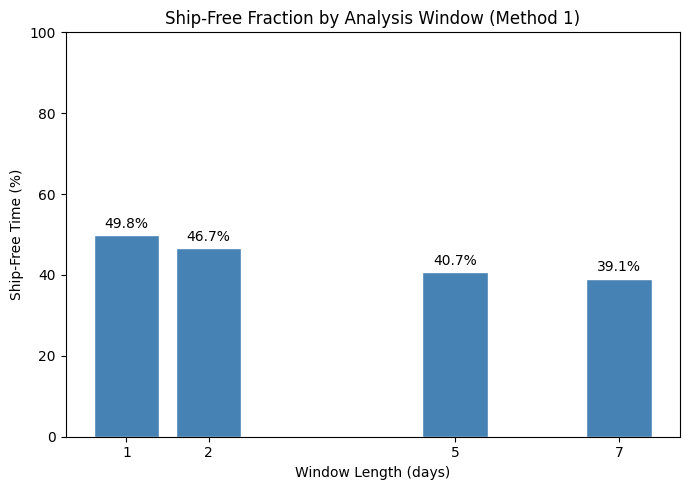

In [115]:
import matplotlib.pyplot as plt

# Convert to pandas for plotting
ship_free_pd = ship_free_df.to_pandas()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(ship_free_pd["window_days"], ship_free_pd["ship_free_pct"] * 100, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel("Window Length (days)")
ax.set_ylabel("Ship-Free Time (%)")
ax.set_title("Ship-Free Fraction by Analysis Window (Method 1)")
ax.set_xticks(ship_free_pd["window_days"])
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Plot D: Ship Presence by Hour of Day

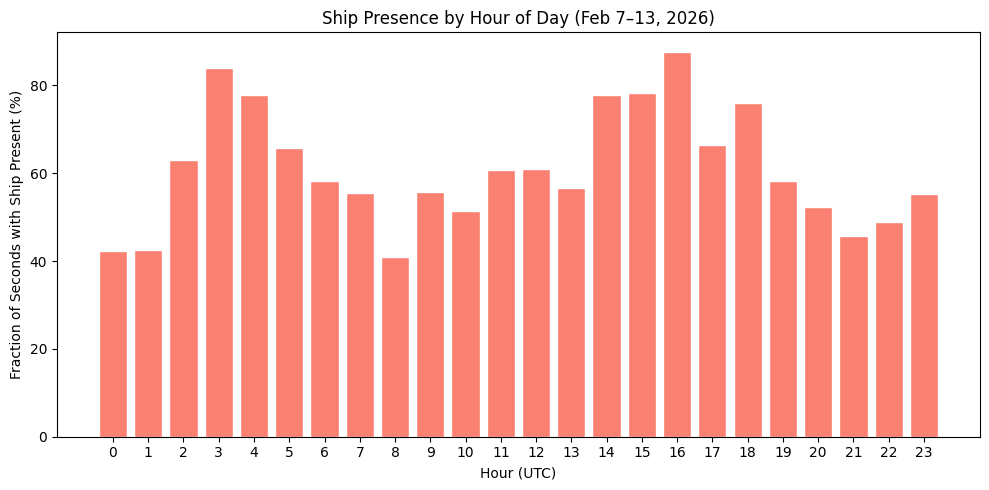

In [116]:
hourly = (
    presence_mask
    .with_columns(pl.col("ts").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(pl.col("ship_present").mean().alias("ship_present_frac"))
    .sort("hour")
)
hourly_pd = hourly.to_pandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly_pd["hour"], hourly_pd["ship_present_frac"] * 100, color="salmon", edgecolor="white")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Fraction of Seconds with Ship Present (%)")
ax.set_title("Ship Presence by Hour of Day (Feb 7–13, 2026)")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 6. Acoustic Data Loading (Full Range)

In [117]:
%%time
# Load broadband for the full 14-day range (ending 2/13, starting 1/31 for 14-day Method 2 windows)
bb_df = accessor.get_time_range(EXTENDED_START, ANALYSIS_END, psd=False)
print(f"Broadband loaded: {bb_df.shape}, range {bb_df['__index_level_0__'].min()} to {bb_df['__index_level_0__'].max()}")

Broadband loaded: (583195, 5), range 2026-02-07 12:18:13 to 2026-02-13 23:59:55
CPU times: user 338 ms, sys: 155 ms, total: 493 ms
Wall time: 3.18 s


In [118]:
%%time
# Load comm band (500–15,000 Hz) for the full range — requires reading all PSD columns, ~30-60 seconds
comm_df = accessor.get_broadband(EXTENDED_START, ANALYSIS_END, COMM_BAND[0], COMM_BAND[1], ref=1)
print(f"Comm band loaded: {comm_df.shape}")

Comm band loaded: (583195, 5)
CPU times: user 2.26 s, sys: 1.9 s, total: 4.16 s
Wall time: 41 s


In [138]:
%%time
# Load ship noise band (20–200 Hz; effective 67–200 Hz given PSD floor at 67 Hz)
ship_band_df = accessor.get_broadband(EXTENDED_START, ANALYSIS_END, SHIP_BAND[0], SHIP_BAND[1], ref=1)
print(f"Ship band loaded: {ship_band_df.shape}")

Ship band loaded: (583195, 5)
CPU times: user 1.6 s, sys: 1.97 s, total: 3.57 s
Wall time: 35.4 s


In [139]:
# Merge broadband, comm band, and ship band into a single acoustic DataFrame
acoustic_df = (
    bb_from_psd.rename({"__index_level_0__": "timestamp", "sound_pressure_level_db": "broadband_db"})
    .select(["timestamp", "broadband_db"])
    .join(
        comm_df.rename({"__index_level_0__": "timestamp", "sound_pressure_level_db": "comm_band_db"})
        .select(["timestamp", "comm_band_db"]),
        on="timestamp",
        how="inner"
    )
    .join(
        ship_band_df.rename({"__index_level_0__": "timestamp", "sound_pressure_level_db": "ship_band_db"})
        .select(["timestamp", "ship_band_db"]),
        on="timestamp",
        how="inner"
    )
    .sort("timestamp")
)
print(f"Merged acoustic_df: {acoustic_df.shape}")
print(f"Date range: {acoustic_df['timestamp'].min()} to {acoustic_df['timestamp'].max()}")
acoustic_df.head(3)

Merged acoustic_df: (731473, 4)
Date range: 2026-02-07 12:18:13 to 2026-02-13 23:59:55


timestamp,broadband_db,comm_band_db,ship_band_db
datetime[ns],f64,f64,f64
2026-02-07 12:18:13,77.343307,77.028356,51.592502
2026-02-07 12:18:14,78.004804,77.682936,53.050175
2026-02-07 12:18:15,78.281081,77.899923,53.117036


## 7. Join Ship-Presence Mask to Acoustic Data

In [140]:
# Left-join ship-presence mask onto acoustic_df by timestamp
# Acoustic rows outside 2/7–2/13 (before ship data) get ship_present = False (null → False)
acoustic_df = (
      acoustic_df
      .join(
          presence_mask.rename({"ts": "timestamp"}).with_columns(
              pl.col("timestamp").cast(pl.Datetime("ns"))
          ),
          on="timestamp",
          how="left"
      )
      .with_columns(pl.col("ship_present").fill_null(False))
  )

# Report ship presence stats for the 2/7–2/13 acoustic window
window_slice = acoustic_df.filter(
    (pl.col("timestamp") >= pl.lit(SHIP_DATA_START)) &
    (pl.col("timestamp") <= pl.lit(ANALYSIS_END))
)
ship_present_count = window_slice["ship_present"].sum()
ship_free_count = len(window_slice) - ship_present_count
print(f"Acoustic rows 2/7–2/13: {len(window_slice):,}")
print(f"  Ship-present: {ship_present_count:,} ({100*ship_present_count/len(window_slice):.1f}%)")
print(f"  Ship-free:    {ship_free_count:,} ({100*ship_free_count/len(window_slice):.1f}%)")
print(f"Total acoustic_df rows: {len(acoustic_df):,}")
acoustic_df.head(3)

Acoustic rows 2/7–2/13: 731,473
  Ship-present: 469,858 (64.2%)
  Ship-free:    261,615 (35.8%)
Total acoustic_df rows: 731,473


timestamp,broadband_db,comm_band_db,ship_band_db,ship_present
datetime[ns],f64,f64,f64,bool
2026-02-07 12:18:13,77.343307,77.028356,51.592502,true
2026-02-07 12:18:14,78.004804,77.682936,53.050175,true
2026-02-07 12:18:15,78.281081,77.899923,53.117036,true


## 8. Method 1 — Ship-Filtered Percentiles

In [141]:
method1_results = []

for d in METHOD1_WINDOWS:
    window_start = ANALYSIS_END - timedelta(days=d)

    window_df = acoustic_df.filter(
        (pl.col("timestamp") >= pl.lit(window_start)) &
        (pl.col("timestamp") <= pl.lit(ANALYSIS_END)) &
        (~pl.col("ship_present"))
    )

    n_seconds = len(window_df)
    if n_seconds == 0:
        print(f"Window {d}d: 0 ship-free seconds — skipping")
        continue

    ship_free_pct_row = ship_free_df.filter(pl.col("window_days") == d)
    sfp = ship_free_pct_row["ship_free_pct"][0] if len(ship_free_pct_row) > 0 else None
    sfp_str = f"{sfp:.3f}" if sfp is not None else "N/A"
    print(f"Window {d}d: {n_seconds:,} ship-free seconds, ship_free_pct={sfp_str}")

    for band, col in [("broadband", "broadband_db"), ("comm_band", "comm_band_db"), ("ship_band", "ship_band_db")]:
        for p in PERCENTILES:
            val = window_df[col].quantile(p)
            method1_results.append({
                "method": "ship_filtered",
                "window_days": d,
                "band": band,
                "percentile": p,
                "value_db": val,
                "n_seconds": n_seconds,
                "ship_free_pct": sfp,
            })

method1_df = pl.DataFrame(method1_results, schema={
    "method": pl.String,
    "window_days": pl.Int64,
    "band": pl.String,
    "percentile": pl.Float64,
    "value_db": pl.Float64,
    "n_seconds": pl.Int64,
    "ship_free_pct": pl.Float64,
})
print(f"\nMethod 1 results: {method1_df.shape}")
method1_df.head(8)

Window 1d: 53,625 ship-free seconds, ship_free_pct=0.498
Window 2d: 102,166 ship-free seconds, ship_free_pct=0.467
Window 5d: 224,632 ship-free seconds, ship_free_pct=0.407
Window 7d: 261,615 ship-free seconds, ship_free_pct=0.391

Method 1 results: (48, 7)


method,window_days,band,percentile,value_db,n_seconds,ship_free_pct
str,i64,str,f64,f64,i64,f64
"""ship_filtered""",1,"""broadband""",0.05,76.419894,53625,0.497841
"""ship_filtered""",1,"""broadband""",0.1,76.752891,53625,0.497841
"""ship_filtered""",1,"""broadband""",0.25,77.530993,53625,0.497841
"""ship_filtered""",1,"""broadband""",0.5,78.092636,53625,0.497841
"""ship_filtered""",1,"""comm_band""",0.05,76.061791,53625,0.497841
"""ship_filtered""",1,"""comm_band""",0.1,76.382216,53625,0.497841
"""ship_filtered""",1,"""comm_band""",0.25,77.144785,53625,0.497841
"""ship_filtered""",1,"""comm_band""",0.5,77.701096,53625,0.497841


## 9. Method 2 — Unfiltered Percentiles

In [123]:
from datetime import timedelta

method2_results = []

for d in METHOD2_WINDOWS:
    if d >= 8:
        continue

    window_start = ANALYSIS_END - timedelta(days=d)

    window_df = acoustic_df.filter(
        (pl.col("timestamp") >= pl.lit(window_start)) &
        (pl.col("timestamp") <= pl.lit(ANALYSIS_END))
    )

    n_seconds = len(window_df)
    if n_seconds == 0:
        print(f"Window {d}d: 0 rows — skipping")
        continue

    for band, col in [("broadband", "broadband_db"), ("comm_band", "comm_band_db"), ("ship_band", "ship_band_db")]:
        for p in PERCENTILES:
            val = window_df[col].quantile(p)
            method2_results.append({
                "method": "unfiltered",
                "window_days": d,
                "band": band,
                "percentile": p,
                "value_db": val,
                "n_seconds": n_seconds,
                "ship_free_pct": None,
            })

    print(f"Window {d}d: {n_seconds:,} rows")

method2_df = pl.DataFrame(method2_results, schema={
    "method": pl.String,
    "window_days": pl.Int64,
    "band": pl.String,
    "percentile": pl.Float64,
    "value_db": pl.Float64,
    "n_seconds": pl.Int64,
    "ship_free_pct": pl.Float64,
})
print(f"\nMethod 2 results: {method2_df.shape}")
method2_df.head(8)

Window 1d: 114,624 rows
Window 2d: 227,230 rows
Window 3d: 339,840 rows
Window 5d: 566,683 rows
Window 7d: 731,473 rows

Method 2 results: (60, 7)


method,window_days,band,percentile,value_db,n_seconds,ship_free_pct
str,i64,str,f64,f64,i64,f64
"""unfiltered""",1,"""broadband""",0.05,76.824375,114624,null
"""unfiltered""",1,"""broadband""",0.1,77.270071,114624,null
"""unfiltered""",1,"""broadband""",0.25,77.830095,114624,null
"""unfiltered""",1,"""broadband""",0.5,78.469925,114624,null
"""unfiltered""",1,"""comm_band""",0.05,76.447741,114624,null
"""unfiltered""",1,"""comm_band""",0.1,76.9669,114624,null
"""unfiltered""",1,"""comm_band""",0.25,77.484727,114624,null
"""unfiltered""",1,"""comm_band""",0.5,78.079513,114624,null


## 10. Results Summary Table

In [124]:
# Combine Method 1 and Method 2 results
results_df = pl.concat([method1_df, method2_df], how="vertical")
print(f"Total results: {results_df.shape} (expected 88 rows)")

# Display as pandas pivot table for readability
results_pd = results_df.to_pandas()
pivot = results_pd.pivot_table(
    index=["method", "window_days"],
    columns=["band", "percentile"],
    values="value_db",
    aggfunc="first"
)
# Format to 1 decimal place
pivot.columns = [f"{b} p{int(p*100)}" for b, p in pivot.columns]
pivot = pivot.round(1)
pivot

Total results: (108, 7) (expected 88 rows)


broadband p5  broadband p10  broadband p25  \
method        window_days                                               
ship_filtered 1                    76.4           76.8           77.5   
              2                    76.4           76.6           77.2   
              5                    76.2           76.5           77.0   
              7                    76.3           76.5           77.0   
unfiltered    1                    76.8           77.3           77.8   
              2                    76.6           77.0           77.7   
              3                    76.5           76.9           77.7   
              5                    76.6           76.9           77.5   
              7                    76.5           76.8           77.5   

                           broadband p50  comm_band p5  comm_band p10  \
method        window_days                                               
ship_filtered 1                     78.1          76.1           76.4   
              2                     77.9          76.1           76.3   
              5                     77.6          75.9           76.2   
              7                     77.6          76.0           76.3   
unfiltered    1                     78.5          76.4           77.0   
              2                     78.4          76.3           76.6   
              3                     78.5          76.2           76.5   
              5                     78.4          76.3           76.6   
              7                     78.3          76.2           76.5   

                           comm_band p25  comm_band p50  ship_band p5  \
method        window_days                                               
ship_filtered 1                     77.1           77.7          41.5   
              2                     76.8           77.5          41.0   
              5                     76.7           77.3          40.7   
              7                     76.7           77.3          41.0   
unfiltered    1                     77.5           78.1          44.4   
              2                     77.4           78.0          42.7   
              3                     77.3           78.2          42.7   
              5                     77.2           78.0          43.2   
              7                     77.1           77.9          43.4   

                           ship_band p10  ship_band p25  ship_band p50  
method        window_days                                               
ship_filtered 1                     44.2           46.6           49.0  
              2                     42.4           46.0           48.9  
              5                     42.6           46.1           48.8  
              7                     43.3           46.6           49.4  
unfiltered    1                     46.1           48.2           52.0  
              2                     45.4           48.4           51.9  
              3                     45.9           49.1           52.7  
              5                     45.7           48.6           52.4  
              7                     45.6           48.7           52.4

## Plot A: Estimated Ambient Level by Method and Window Length

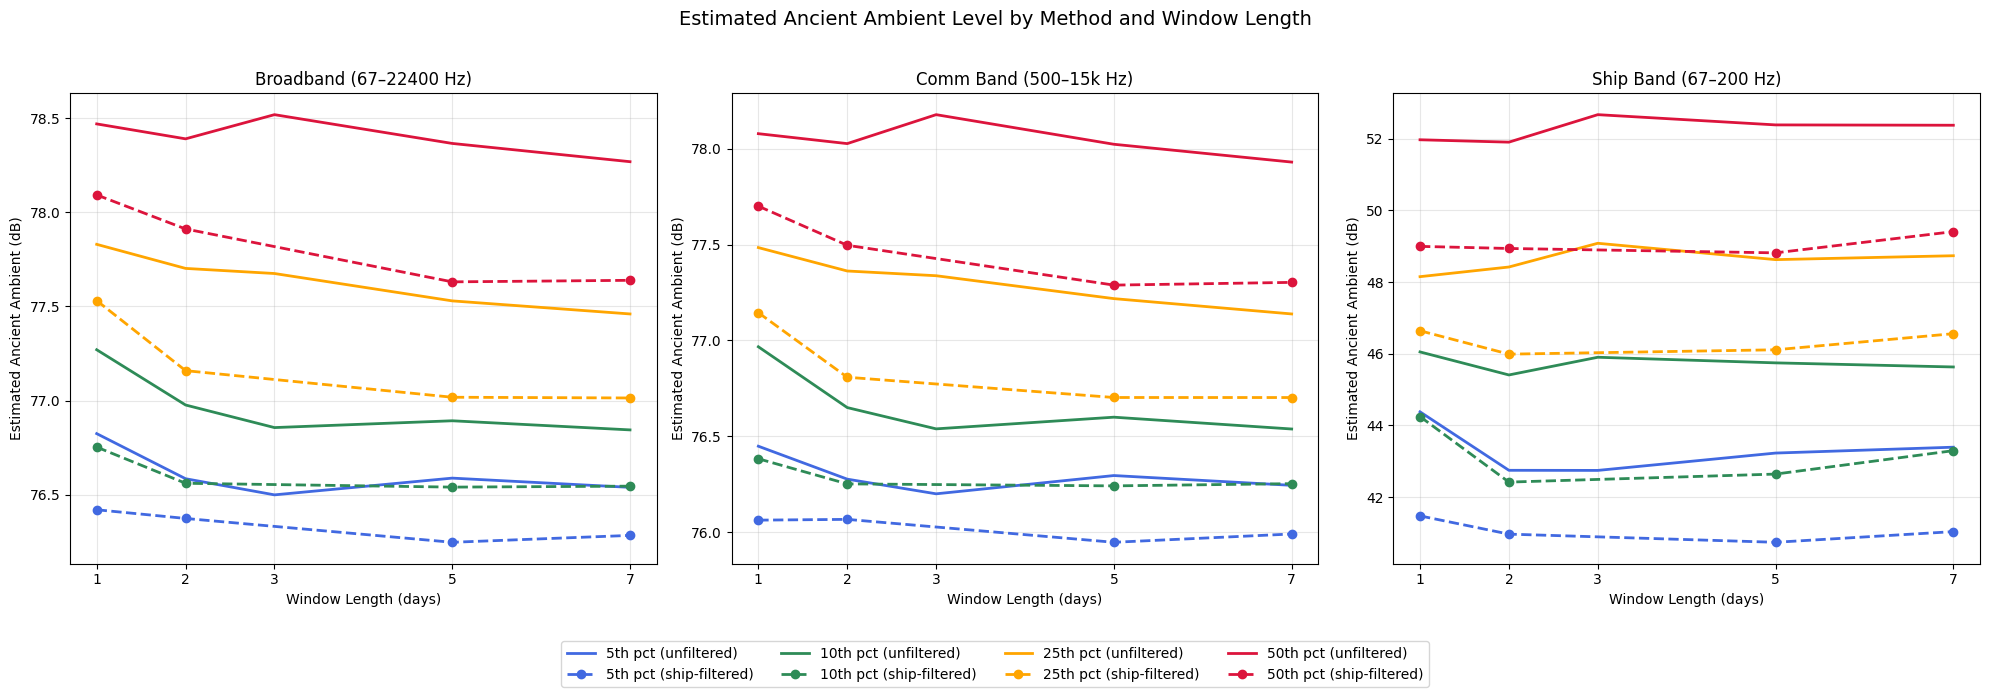

In [125]:
import matplotlib.pyplot as plt
import numpy as np

results_pd = results_df.to_pandas()
available_windows = sorted(results_pd["window_days"].dropna().unique().tolist())
results_pd = results_pd[results_pd["window_days"].isin(available_windows)]

bands = ["broadband", "comm_band", "ship_band"]
band_labels = {"broadband": "Broadband (67–22400 Hz)", "comm_band": "Comm Band (500–15k Hz)", "ship_band": "Ship Band (67–200 Hz)"}
colors = {0.05: "royalblue", 0.10: "seagreen", 0.25: "orange", 0.50: "crimson"}
pct_labels = {0.05: "5th pct", 0.10: "10th pct", 0.25: "25th pct", 0.50: "50th pct"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, band in zip(axes, bands):
    m2 = results_pd[(results_pd["method"] == "unfiltered") & (results_pd["band"] == band)]
    m1 = results_pd[(results_pd["method"] == "ship_filtered") & (results_pd["band"] == band)]

    for p in PERCENTILES:
        color = colors[p]
        label = pct_labels[p]
        d2 = m2[m2["percentile"] == p].sort_values("window_days")
        if len(d2) > 0:
            ax.plot(d2["window_days"], d2["value_db"], color=color, linewidth=2, label=f"{label} (unfiltered)")
        d1 = m1[m1["percentile"] == p].sort_values("window_days")
        if len(d1) > 0:
            ax.plot(d1["window_days"], d1["value_db"], color=color, linewidth=2,
                    linestyle="--", marker="o", markersize=6, label=f"{label} (ship-filtered)")

    ax.set_title(band_labels[band])
    ax.set_xlabel("Window Length (days)")
    ax.set_ylabel("Estimated Ancient Ambient (dB)")
    ax.set_xticks(available_windows)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.suptitle("Estimated Ancient Ambient Level by Method and Window Length", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [126]:
import pandas as pd

# Display just the 5th percentile results
p5_pd = results_df.to_pandas()
p5_pd = p5_pd[p5_pd["percentile"] == 0.05].copy()

p5_pivot = (
    p5_pd.pivot_table(
        index=["method", "window_days"],
        columns="band",
        values="value_db",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(["method", "window_days"])
)

p5_pivot = p5_pivot.rename(
    columns={
        "broadband": "broadband_p5_db",
        "comm_band": "comm_band_p5_db",
    }
)

p5_pivot.round(2)

band,method,window_days,broadband_p5_db,comm_band_p5_db,ship_band
0,ship_filtered,1,76.42,76.06,41.48
1,ship_filtered,2,76.37,76.07,40.97
2,ship_filtered,5,76.25,75.95,40.74
3,ship_filtered,7,76.28,75.99,41.04
4,unfiltered,1,76.82,76.45,44.38
5,unfiltered,2,76.58,76.28,42.75
6,unfiltered,3,76.50,76.20,42.74
7,unfiltered,5,76.59,76.29,43.23
8,unfiltered,7,76.54,76.24,43.39


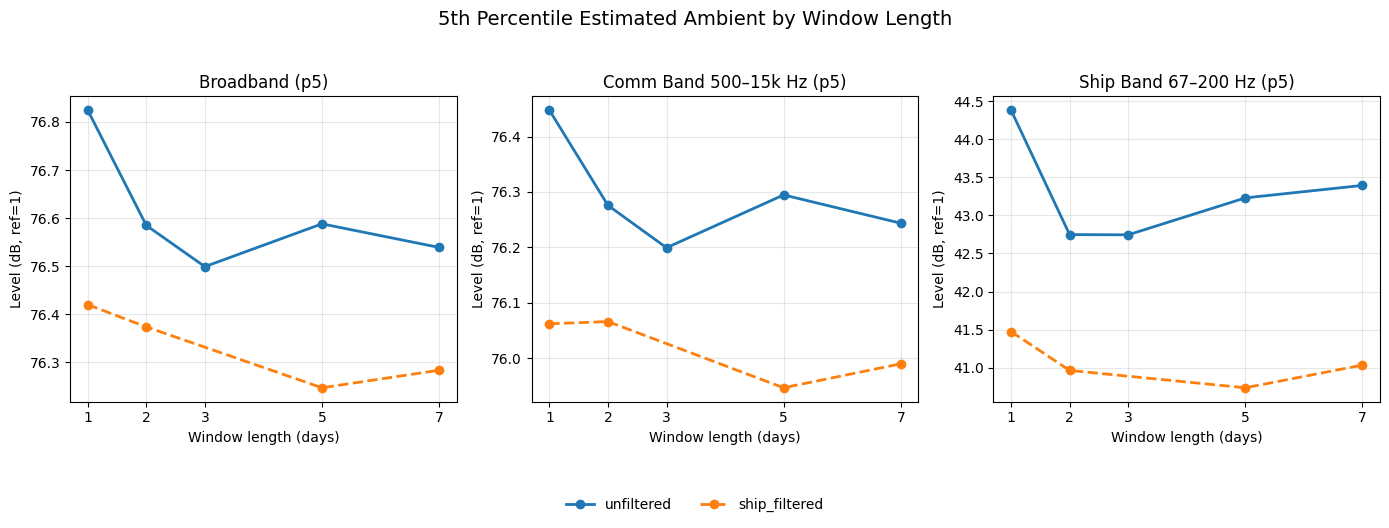

In [142]:
import matplotlib.pyplot as plt

# Visualization of 5th percentiles (Method 1 vs Method 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

plot_specs = [
    ("broadband_p5_db", "Broadband (p5)"),
    ("comm_band_p5_db", "Comm Band 500–15k Hz (p5)"),
    ("ship_band", "Ship Band 67–200 Hz (p5)"),
]

for ax, (col, title) in zip(axes, plot_specs):
    for method, style in [("unfiltered", "-"), ("ship_filtered", "--")]:
        d = p5_pivot[p5_pivot["method"] == method].sort_values("window_days")
        if col not in d.columns:
            continue
        ax.plot(
            d["window_days"],
            d[col],
            linestyle=style,
            marker="o",
            linewidth=2,
            label=method,
        )

    ax.set_title(title)
    ax.set_xlabel("Window length (days)")
    ax.set_ylabel("Level (dB, ref=1)")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(p5_pivot["window_days"].unique().tolist()))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("5th Percentile Estimated Ambient by Window Length", fontsize=14)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

## Plot B: 5th Percentile Ancient Ambient — Ship-Filtered vs Unfiltered

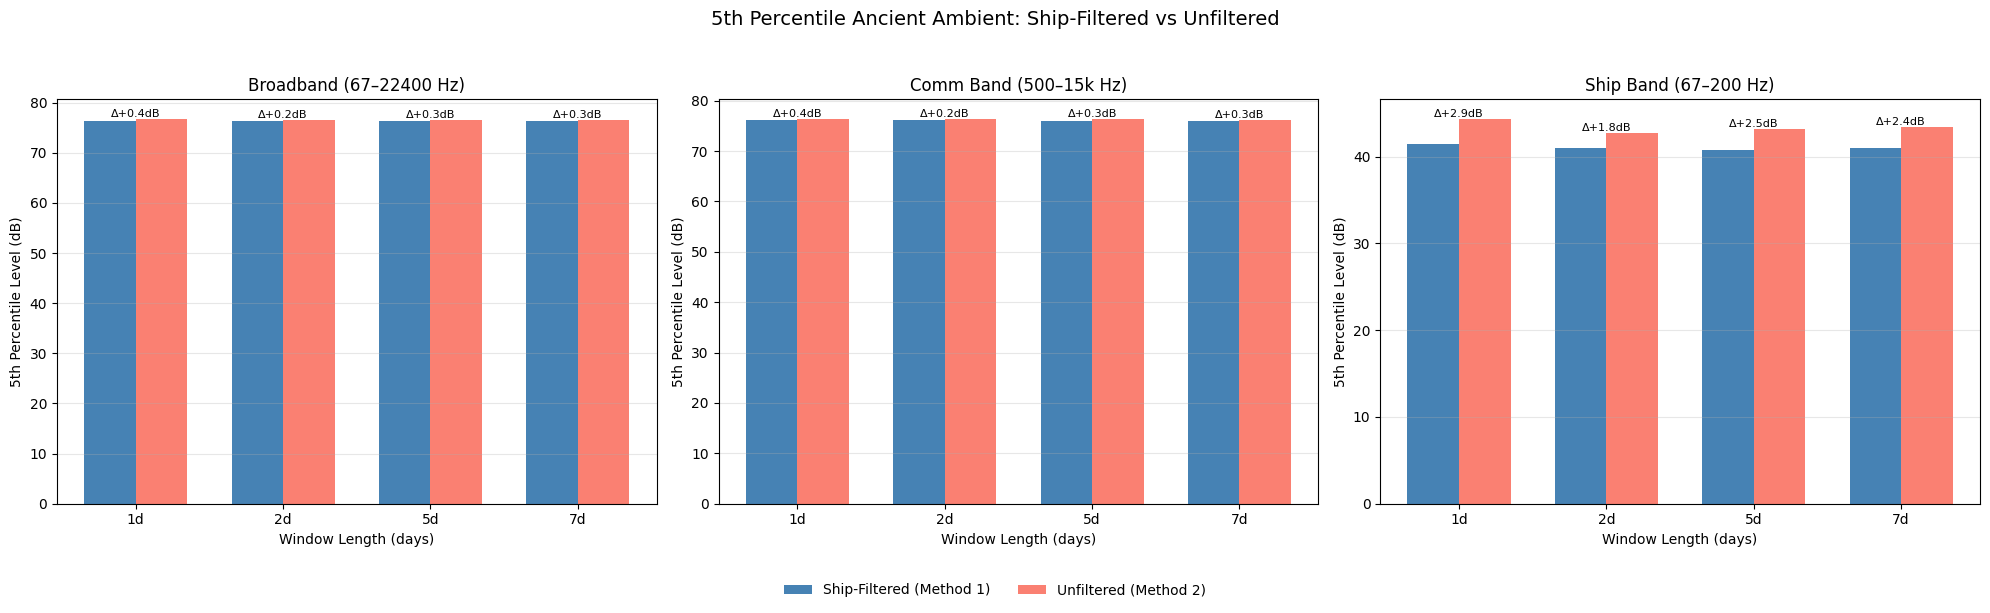

In [128]:
shared_windows = [1, 2, 5, 7]
target_pct = 0.05

results_pd_local = results_df.to_pandas()
bands = ["broadband", "comm_band", "ship_band"]
band_labels = {"broadband": "Broadband (67–22400 Hz)", "comm_band": "Comm Band (500–15k Hz)", "ship_band": "Ship Band (67–200 Hz)"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
bar_width = 0.35
x = np.arange(len(shared_windows))

for ax, band in zip(axes, bands):
    m1_vals, m2_vals = [], []
    for d in shared_windows:
        v1 = results_pd_local[
            (results_pd_local["method"] == "ship_filtered") & (results_pd_local["band"] == band) &
            (results_pd_local["percentile"] == target_pct) & (results_pd_local["window_days"] == d)
        ]["value_db"].values
        m1_vals.append(v1[0] if len(v1) > 0 else float("nan"))

        v2 = results_pd_local[
            (results_pd_local["method"] == "unfiltered") & (results_pd_local["band"] == band) &
            (results_pd_local["percentile"] == target_pct) & (results_pd_local["window_days"] == d)
        ]["value_db"].values
        m2_vals.append(v2[0] if len(v2) > 0 else float("nan"))

    ax.bar(x - bar_width / 2, m1_vals, bar_width, label="Ship-Filtered (Method 1)", color="steelblue")
    ax.bar(x + bar_width / 2, m2_vals, bar_width, label="Unfiltered (Method 2)", color="salmon")

    for i, (v1, v2) in enumerate(zip(m1_vals, m2_vals)):
        if not (np.isnan(v1) or np.isnan(v2)):
            diff = v2 - v1
            ax.annotate(f"Δ{diff:+.1f}dB", xy=(x[i], max(v1, v2)), ha="center", va="bottom", fontsize=8)

    ax.set_title(band_labels[band])
    ax.set_xlabel("Window Length (days)")
    ax.set_ylabel("5th Percentile Level (dB)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{d}d" for d in shared_windows])
    ax.grid(True, alpha=0.3, axis="y")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("5th Percentile Ancient Ambient: Ship-Filtered vs Unfiltered", fontsize=14)
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

## 11. Interpretation and Findings

*Fill in after running the notebook end-to-end with valid AWS credentials.*

### Key Questions This Analysis Addresses

**Does ship filtering change the ambient estimate?**  
Compare the Δ values in Plot B. If Method 1 (ship-filtered) gives systematically lower 5th-percentile estimates than Method 2 (unfiltered) by more than ~1–2 dB, ship activity meaningfully biases the unfiltered ambient baseline. A small Δ (< 1 dB) suggests ship filtering provides little additional value at this location/period.

**Does the estimate stabilize with longer windows?**  
In Plot A, look for convergence: if the lines flatten out by ~5–7 days, shorter windows are adequate. If values continue drifting with longer windows, more data is needed for a stable estimate.

**Which band is more sensitive to ship filtering?**  
Ships produce broadband noise, but the orca communication band (500–15,000 Hz) may show stronger ship contamination. Compare the Δ values in Plot B across the two subplots.

**Recommended method and window length:**  
Based on the analysis:
- If ship-filtering changes the 5th percentile by > 1 dB consistently: **use Method 1 (ship-filtered)** with the longest available window (7 days for the current ship data period).
- If ship-filtering has negligible effect: **use Method 2 (unfiltered)** with a 7–14 day window, which provides more stable estimates from a larger sample.

### Data Notes

- Ship metrics cover 2026-02-07 to 2026-02-13 (7 days). Method 1 is limited to this period.
- Acoustic data is loaded from 2026-01-31 to 2026-02-13, enabling Method 2 windows up to 14 days.
- Ship confidence threshold: ≥ 0.5. Tracks below this threshold are excluded from the ship-free mask.
- The `bb_series` column in ship metrics shows constant −171.64 dB for many ships (= negated `bb_ref` constant), indicating missing acoustic coverage during those passages. This analysis uses raw PartitionedAccessor data directly and does not rely on ship-metrics acoustic values.

## 12. Cumulative 5th Percentile — Growing Window from Feb 1

In [129]:
%%time
# Load full February broadband (PSD-derived, ref=1) from 2/1 through today
FEB_START = datetime(2026, 2, 1)
FEB_END = datetime(2026, 2, 22, 23, 59, 59)

feb_bb = (
    accessor.get_broadband(FEB_START, FEB_END, 67, 22400, ref=1)
    .rename({"__index_level_0__": "timestamp", "sound_pressure_level_db": "broadband_db"})
    .select(["timestamp", "broadband_db"])
    .sort("timestamp")
)

ts_dtype = feb_bb["timestamp"].dtype
print(f"Loaded: {feb_bb.shape}, dtype={ts_dtype}")
print(f"Date range: {feb_bb['timestamp'].min()} to {feb_bb['timestamp'].max()}")

Loaded: (733888, 2), dtype=Datetime(time_unit='ns', time_zone=None)
Date range: 2026-02-07 12:18:13 to 2026-02-22 21:47:37
CPU times: user 2.58 s, sys: 2.76 s, total: 5.34 s
Wall time: 33.3 s


In [130]:
# Gap analysis: build a complete 1-second spine and find missing periods
spine = pl.DataFrame({
    "timestamp": pl.datetime_range(FEB_START, FEB_END, interval="1s", eager=True).cast(ts_dtype)
})

gap_df = spine.join(
    feb_bb.select("timestamp").with_columns(pl.lit(True).alias("has_data")),
    on="timestamp",
    how="left"
).with_columns(pl.col("has_data").fill_null(False))

total_s = len(spine)
data_s = gap_df["has_data"].sum()
print(f"Total seconds Feb 1–22 : {total_s:,}")
print(f"Seconds with data      : {data_s:,} ({100*data_s/total_s:.1f}%)")
print(f"Gap seconds            : {total_s - data_s:,} ({100*(total_s-data_s)/total_s:.1f}%)")

# Find contiguous gap periods using run-length encoding
gap_periods = (
    gap_df
    .filter(~pl.col("has_data"))
    .with_columns(
        (pl.col("timestamp").diff().dt.total_seconds().fill_null(1) > 1)
        .cast(pl.Int32).cum_sum().alias("gap_id")
    )
    .group_by("gap_id")
    .agg([
        pl.col("timestamp").min().alias("gap_start"),
        pl.col("timestamp").max().alias("gap_end"),
        pl.len().alias("gap_seconds"),
    ])
    .sort("gap_start")
)
print(f"\nContiguous gap periods: {len(gap_periods)}")
print(f"Longest gap: {gap_periods['gap_seconds'].max():,} seconds ({gap_periods['gap_seconds'].max()/3600:.1f} hours)")
gap_periods

Total seconds Feb 1–22 : 1,900,800
Seconds with data      : 733,888 (38.6%)
Gap seconds            : 1,166,912 (61.4%)

Contiguous gap periods: 32
Longest gap: 562,693 seconds (156.3 hours)


gap_id,gap_start,gap_end,gap_seconds
i32,datetime[ns],datetime[ns],u32
0,2026-02-01 00:00:00,2026-02-07 12:18:12,562693
1,2026-02-07 23:54:59,2026-02-08 00:00:22,324
2,2026-02-08 23:52:43,2026-02-09 00:00:24,462
3,2026-02-09 23:53:26,2026-02-10 00:00:21,416
4,2026-02-10 23:50:29,2026-02-11 00:00:22,594
…,…,…,…
27,2026-02-21 04:26:20,2026-02-21 09:17:29,17470
28,2026-02-21 10:02:29,2026-02-21 10:42:50,2422
29,2026-02-21 12:49:12,2026-02-21 13:17:13,1682


In [131]:
# Cumulative percentiles: each day looks back to Feb 1
percentiles = [0.01, 0.02, 0.03, 0.04, 0.05]

cumulative = []
for day in range(1, 23):  # Feb 1 through Feb 22
    window_end = datetime(2026, 2, day, 23, 59, 59)
    window_df = feb_bb.filter(pl.col("timestamp") <= pl.lit(window_end).cast(ts_dtype))
    n = len(window_df)

    row = {"date": datetime(2026, 2, day), "n_seconds": n}
    for p in percentiles:
        key = f"p{int(p * 100)}_db"
        row[key] = window_df["broadband_db"].quantile(p) if n > 0 else None

    cumulative.append(row)

    def fmt(v):
        return f"{v:.2f} dB" if v is not None else "no data"

    print(
        f"2/{day:02d}: {n:>7,} seconds cumulative, "
        f"p1={fmt(row['p1_db'])}, p2={fmt(row['p2_db'])}, p3={fmt(row['p3_db'])}, "
        f"p4={fmt(row['p4_db'])}, p5={fmt(row['p5_db'])}"
    )

cumulative_df = pl.DataFrame(cumulative)

2/01:       0 seconds cumulative, p1=no data, p2=no data, p3=no data, p4=no data, p5=no data
2/02:       0 seconds cumulative, p1=no data, p2=no data, p3=no data, p4=no data, p5=no data
2/03:       0 seconds cumulative, p1=no data, p2=no data, p3=no data, p4=no data, p5=no data
2/04:       0 seconds cumulative, p1=no data, p2=no data, p3=no data, p4=no data, p5=no data
2/05:       0 seconds cumulative, p1=no data, p2=no data, p3=no data, p4=no data, p5=no data
2/06:       0 seconds cumulative, p1=no data, p2=no data, p3=no data, p4=no data, p5=no data
2/07:  42,888 seconds cumulative, p1=76.69 dB, p2=76.77 dB, p3=76.84 dB, p4=76.89 dB, p5=76.94 dB
2/08: 133,038 seconds cumulative, p1=76.12 dB, p2=76.26 dB, p3=76.34 dB, p4=76.40 dB, p5=76.45 dB
2/09: 223,565 seconds cumulative, p1=76.17 dB, p2=76.32 dB, p3=76.42 dB, p4=76.49 dB, p5=76.56 dB
2/10: 312,691 seconds cumulative, p1=76.12 dB, p2=76.31 dB, p3=76.42 dB, p4=76.51 dB, p5=76.58 dB
2/11: 402,657 seconds cumulative, p1=75.86 dB, p2=

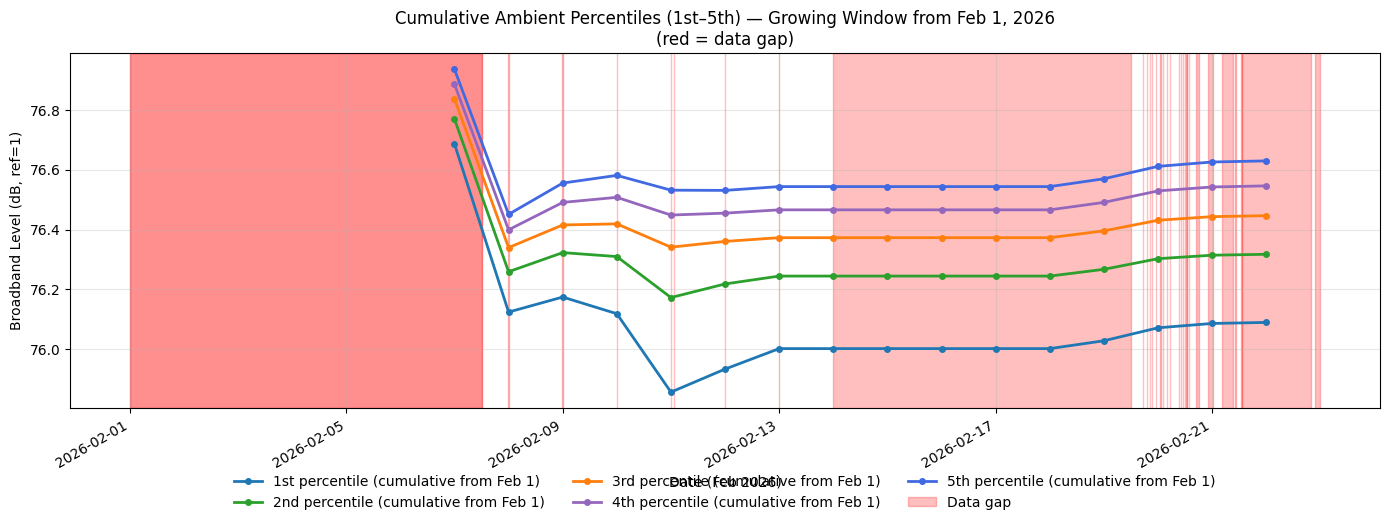

In [132]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

cum_pd = cumulative_df.to_pandas()
cum_pd["date"] = pd.to_datetime(cum_pd["date"])
gap_pd = gap_periods.to_pandas()
gap_pd["gap_start"] = pd.to_datetime(gap_pd["gap_start"])
gap_pd["gap_end"] = pd.to_datetime(gap_pd["gap_end"])

fig, ax = plt.subplots(figsize=(14, 6))

# Shade data gaps
for _, row in gap_pd.iterrows():
    ax.axvspan(row["gap_start"], row["gap_end"], alpha=0.25, color="red", zorder=1)

# Shade periods with no data at all (before first data point)
first_data = feb_bb["timestamp"].min()
if pd.to_datetime(first_data) > pd.Timestamp(FEB_START):
    ax.axvspan(pd.Timestamp(FEB_START), pd.to_datetime(first_data), alpha=0.25, color="red", zorder=1)

# Cumulative percentile lines (1st–5th)
pcts = [
    ("p1_db", "1st", "#1f77b4"),
    ("p2_db", "2nd", "#2ca02c"),
    ("p3_db", "3rd", "#ff7f0e"),
    ("p4_db", "4th", "#9467bd"),
    ("p5_db", "5th", "royalblue"),
]

line_handles = []
for col, ordinal, color in pcts:
    has_data = cum_pd[cum_pd[col].notna()]
    (line,) = ax.plot(
        has_data["date"],
        has_data[col],
        color=color,
        linewidth=2,
        marker="o",
        markersize=4,
        zorder=3,
        label=f"{ordinal} percentile (cumulative from Feb 1)",
    )
    line_handles.append(line)

gap_handle = mpatches.Patch(color="red", alpha=0.25, label="Data gap")

ax.set_xlabel("Date (Feb 2026)")
ax.set_ylabel("Broadband Level (dB, ref=1)")
ax.set_title("Cumulative Ambient Percentiles (1st–5th) — Growing Window from Feb 1, 2026\n(red = data gap)")
ax.grid(True, alpha=0.3, zorder=0)

# Legend below chart (keeps keys off the plot)
ax.legend(
    handles=[*line_handles, gap_handle],
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.32),
)

fig.autofmt_xdate()
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## 13. Rolling 5th Percentile — 1, 3, 5, 7 Day Windows

In [133]:
# Rolling 5th percentile: for each day, look back exactly N days
ROLLING_WINDOWS = [1, 3, 5, 7]
rolling_results = []

for day in range(1, 23):  # Feb 1 through Feb 22
    day_end = datetime(2026, 2, day, 23, 59, 59)
    for w in ROLLING_WINDOWS:
        day_start = datetime(2026, 2, day) - timedelta(days=w - 1)
        # Clamp to FEB_START so early days don't go negative
        day_start = max(day_start, FEB_START)
        window_df = feb_bb.filter(
            (pl.col("timestamp") >= pl.lit(day_start).cast(ts_dtype)) &
            (pl.col("timestamp") <= pl.lit(day_end).cast(ts_dtype))
        )
        n = len(window_df)
        p5 = window_df["broadband_db"].quantile(0.05) if n > 0 else None
        rolling_results.append({
            "date": datetime(2026, 2, day),
            "window_days": w,
            "n_seconds": n,
            "p5_db": p5,
        })

rolling_df = pl.DataFrame(rolling_results)
print(f"Rolling results: {rolling_df.shape}")
rolling_df.head(8)

Rolling results: (88, 4)


date,window_days,n_seconds,p5_db
datetime[μs],i64,i64,f64
2026-02-01 00:00:00,1,0,null
2026-02-01 00:00:00,3,0,null
2026-02-01 00:00:00,5,0,null
2026-02-01 00:00:00,7,0,null
2026-02-02 00:00:00,1,0,null
2026-02-02 00:00:00,3,0,null
2026-02-02 00:00:00,5,0,null
2026-02-02 00:00:00,7,0,null


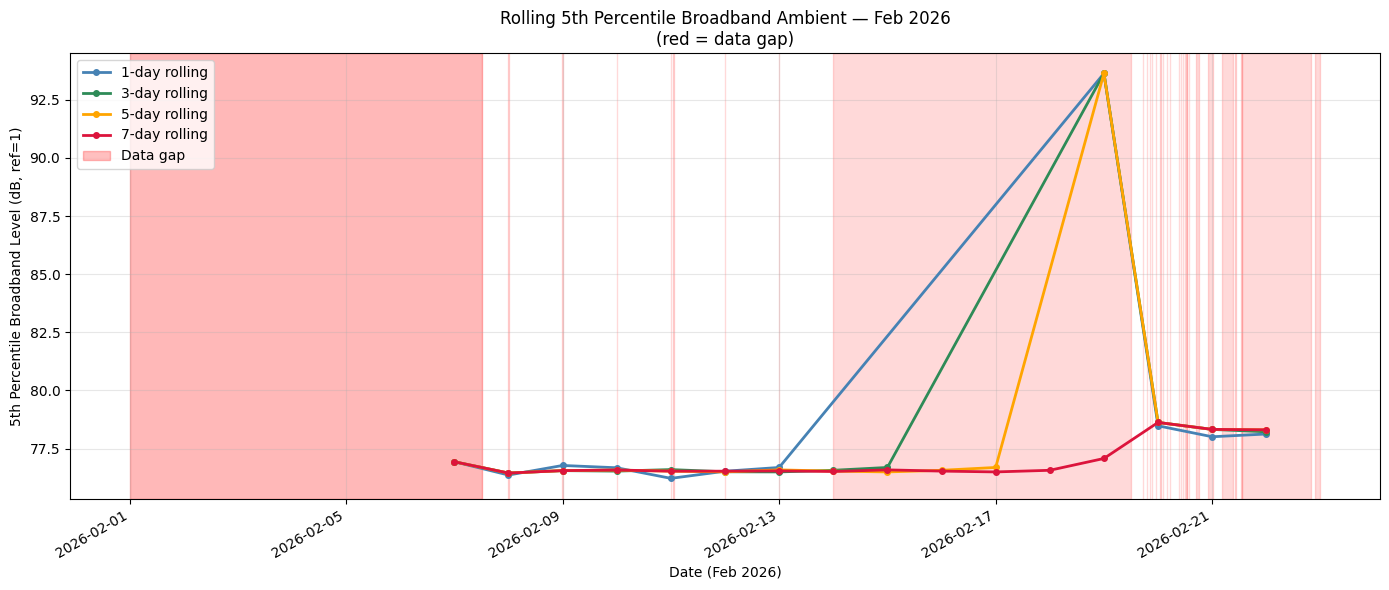

In [134]:
rolling_pd = rolling_df.to_pandas()
rolling_pd["date"] = pd.to_datetime(rolling_pd["date"])

colors = {1: "steelblue", 3: "seagreen", 5: "orange", 7: "crimson"}

fig, ax = plt.subplots(figsize=(14, 6))

# Shade data gaps (reuse gap_pd from Section 12)
for _, row in gap_pd.iterrows():
    ax.axvspan(row["gap_start"], row["gap_end"], alpha=0.15, color="red", zorder=1)
if pd.to_datetime(feb_bb["timestamp"].min()) > pd.Timestamp(FEB_START):
    ax.axvspan(pd.Timestamp(FEB_START), pd.to_datetime(feb_bb["timestamp"].min()),
               alpha=0.15, color="red", zorder=1)

# One line per rolling window
for w in ROLLING_WINDOWS:
    subset = rolling_pd[(rolling_pd["window_days"] == w) & rolling_pd["p5_db"].notna()]
    ax.plot(subset["date"], subset["p5_db"],
            color=colors[w], linewidth=2, marker="o", markersize=4, zorder=3,
            label=f"{w}-day rolling")

ax.set_xlabel("Date (Feb 2026)")
ax.set_ylabel("5th Percentile Broadband Level (dB, ref=1)")
ax.set_title("Rolling 5th Percentile Broadband Ambient — Feb 2026\n(red = data gap)")
ax.grid(True, alpha=0.3, zorder=0)

gap_handle = mpatches.Patch(color="red", alpha=0.25, label="Data gap")
ax.legend(handles=[*ax.lines, gap_handle])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 12b. Ship Band Cumulative & Rolling Percentiles — Feb 1 to Present

In [ ]:
%%time
# Load February ship band (PSD-derived, 67–200 Hz effective, ref=1) from 2/1 through today
feb_ship = (
    accessor.get_broadband(FEB_START, FEB_END, SHIP_BAND[0], SHIP_BAND[1], ref=1)
    .rename({"__index_level_0__": "timestamp", "sound_pressure_level_db": "ship_band_db"})
    .select(["timestamp", "ship_band_db"])
    .sort("timestamp")
)

ship_ts_dtype = feb_ship["timestamp"].dtype
print(f"Loaded: {feb_ship.shape}, dtype={ship_ts_dtype}")
print(f"Date range: {feb_ship['timestamp'].min()} to {feb_ship['timestamp'].max()}")

In [ ]:
# Cumulative percentiles (1st–5th) for ship band: each day looks back to Feb 1
ship_percentiles = [0.01, 0.02, 0.03, 0.04, 0.05]

cumulative_ship = []
for day in range(1, 23):  # Feb 1 through Feb 22
    window_end = datetime(2026, 2, day, 23, 59, 59)
    window_df = feb_ship.filter(pl.col("timestamp") <= pl.lit(window_end).cast(ship_ts_dtype))
    n = len(window_df)

    row = {"date": datetime(2026, 2, day), "n_seconds": n}
    for p in ship_percentiles:
        key = f"p{int(p * 100)}_db"
        row[key] = window_df["ship_band_db"].quantile(p) if n > 0 else None

    cumulative_ship.append(row)

    def fmt(v):
        return f"{v:.2f} dB" if v is not None else "no data"

    print(
        f"2/{day:02d}: {n:>7,} seconds cumulative, "
        f"p1={fmt(row['p1_db'])}, p2={fmt(row['p2_db'])}, p3={fmt(row['p3_db'])}, "
        f"p4={fmt(row['p4_db'])}, p5={fmt(row['p5_db'])}"
    )

cumulative_ship_df = pl.DataFrame(cumulative_ship)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

cum_ship_pd = cumulative_ship_df.to_pandas()
cum_ship_pd["date"] = pd.to_datetime(cum_ship_pd["date"])

fig, ax = plt.subplots(figsize=(14, 6))

# Shade data gaps (reuse gap_pd from Section 12)
for _, row in gap_pd.iterrows():
    ax.axvspan(row["gap_start"], row["gap_end"], alpha=0.25, color="red", zorder=1)
if pd.to_datetime(feb_ship["timestamp"].min()) > pd.Timestamp(FEB_START):
    ax.axvspan(pd.Timestamp(FEB_START), pd.to_datetime(feb_ship["timestamp"].min()),
               alpha=0.25, color="red", zorder=1)

pcts = [
    ("p1_db", "1st", "#1f77b4"),
    ("p2_db", "2nd", "#2ca02c"),
    ("p3_db", "3rd", "#ff7f0e"),
    ("p4_db", "4th", "#9467bd"),
    ("p5_db", "5th", "royalblue"),
]

line_handles = []
for col, ordinal, color in pcts:
    has_data = cum_ship_pd[cum_ship_pd[col].notna()]
    (line,) = ax.plot(
        has_data["date"],
        has_data[col],
        color=color,
        linewidth=2,
        marker="o",
        markersize=4,
        zorder=3,
        label=f"{ordinal} percentile (cumulative from Feb 1)",
    )
    line_handles.append(line)

gap_handle = mpatches.Patch(color="red", alpha=0.25, label="Data gap")

ax.set_xlabel("Date (Feb 2026)")
ax.set_ylabel(f"Ship Band Level (dB, ref=1)\n({SHIP_BAND[0]}\u2013{SHIP_BAND[1]} Hz effective: 67\u2013200 Hz)")
ax.set_title(
    f"Ship Band ({SHIP_BAND[0]}\u2013{SHIP_BAND[1]} Hz) Cumulative Percentiles (1st\u20135th)\n"
    "Growing Window from Feb 1, 2026  (red = data gap)"
)
ax.grid(True, alpha=0.3, zorder=0)

ax.legend(
    handles=[*line_handles, gap_handle],
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.32),
)

fig.autofmt_xdate()
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [ ]:
# Rolling 5th percentile for ship band: for each day, look back exactly N days
rolling_ship_results = []

for day in range(1, 23):  # Feb 1 through Feb 22
    day_end = datetime(2026, 2, day, 23, 59, 59)
    for w in ROLLING_WINDOWS:
        day_start = datetime(2026, 2, day) - timedelta(days=w - 1)
        day_start = max(day_start, FEB_START)
        window_df = feb_ship.filter(
            (pl.col("timestamp") >= pl.lit(day_start).cast(ship_ts_dtype)) &
            (pl.col("timestamp") <= pl.lit(day_end).cast(ship_ts_dtype))
        )
        n = len(window_df)
        p5 = window_df["ship_band_db"].quantile(0.05) if n > 0 else None
        rolling_ship_results.append({
            "date": datetime(2026, 2, day),
            "window_days": w,
            "n_seconds": n,
            "p5_db": p5,
        })

rolling_ship_df = pl.DataFrame(rolling_ship_results)
print(f"Rolling ship band results: {rolling_ship_df.shape}")
rolling_ship_df.head(8)

In [ ]:
rolling_ship_pd = rolling_ship_df.to_pandas()
rolling_ship_pd["date"] = pd.to_datetime(rolling_ship_pd["date"])

colors = {1: "steelblue", 3: "seagreen", 5: "orange", 7: "crimson"}

fig, ax = plt.subplots(figsize=(14, 6))

# Shade data gaps (reuse gap_pd from Section 12)
for _, row in gap_pd.iterrows():
    ax.axvspan(row["gap_start"], row["gap_end"], alpha=0.15, color="red", zorder=1)
if pd.to_datetime(feb_ship["timestamp"].min()) > pd.Timestamp(FEB_START):
    ax.axvspan(pd.Timestamp(FEB_START), pd.to_datetime(feb_ship["timestamp"].min()),
               alpha=0.15, color="red", zorder=1)

line_handles = []
for w in ROLLING_WINDOWS:
    subset = rolling_ship_pd[(rolling_ship_pd["window_days"] == w) & rolling_ship_pd["p5_db"].notna()]
    (line,) = ax.plot(
        subset["date"], subset["p5_db"],
        color=colors[w], linewidth=2, marker="o", markersize=4, zorder=3,
        label=f"{w}-day rolling"
    )
    line_handles.append(line)

ax.set_xlabel("Date (Feb 2026)")
ax.set_ylabel(f"5th Percentile Ship Band Level (dB, ref=1)\n({SHIP_BAND[0]}\u2013{SHIP_BAND[1]} Hz effective: 67\u2013200 Hz)")
ax.set_title(
    f"Rolling 5th Percentile Ship Band Ambient ({SHIP_BAND[0]}\u2013{SHIP_BAND[1]} Hz) \u2014 Feb 2026\n"
    "(red = data gap)"
)
ax.grid(True, alpha=0.3, zorder=0)

gap_handle = mpatches.Patch(color="red", alpha=0.25, label="Data gap")
ax.legend(handles=[*line_handles, gap_handle])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()